In [2]:
# Librerías generales de datos y visualización
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Librerías de Machine Learning (Scikit-Learn)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [3]:

######## Primero subimos el archivo 
archivo = 'ai4i2020.csv' 
df = pd.read_csv(archivo)

######### Y tomamos una muestra de los datos para verlos
print("Vista previa de los datos")
display(df.head())

######### Imprimimos la ficha tecnica del dataset
print("\nInformación del dataset")
print(f"Fuente: UCI Machine Learning Repository")
print(f"Tamaño (Filas, Columnas): {df.shape}")
print("\nTipos de Variables:")
print(df.dtypes)

######### Verificamos el balance de clases
conteo = df['Machine failure'].value_counts()
print("\nDistribución de fallas")
print(f"Máquinas OK (0): {conteo[0]}")
print(f"Máquinas con Falla (1): {conteo[1]}")

######## Elimina las columnas que no son relevantes para el modelo a
df_clean = df.drop(columns=['UDI', 'Product ID'])

######## Las variables categoricas se convierten en variables dummy
df_clean = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)

Vista previa de los datos


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Información del dataset
Fuente: UCI Machine Learning Repository
Tamaño (Filas, Columnas): (10000, 14)

Tipos de Variables:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Distribución de fallas
Máquinas OK (0): 9661
Máquinas con Falla (1): 339


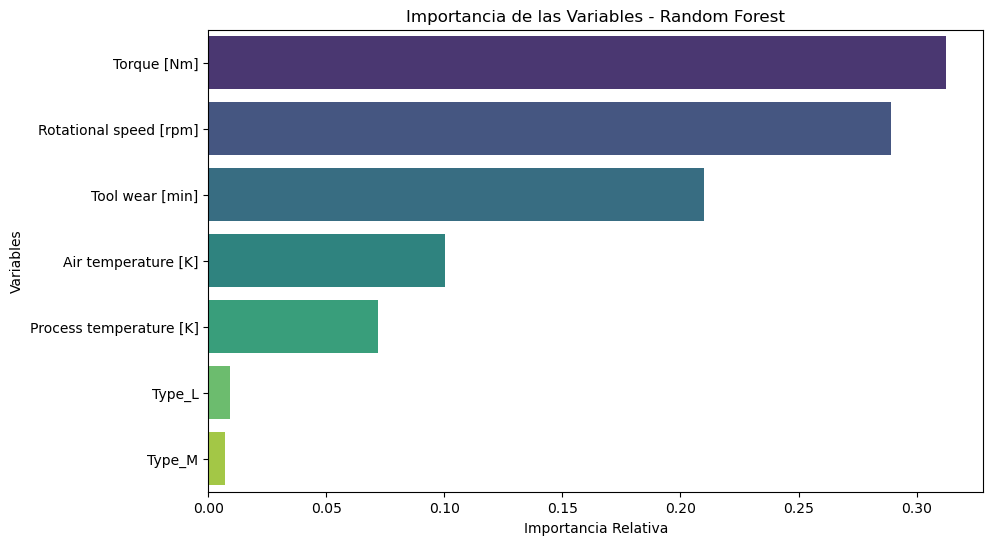

REPORTE DE CLASIFICACIÓN - MODELO LINEAL (Regresión Logística)
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000

Iniciando búsqueda de hiperparámetros... (esto puede tardar unos segundos)

¡Listo! Mejores hiperparámetros encontrados: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}

REPORTE DE CLASIFICACIÓN - SVM OPTIMIZADO
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      1932
           1       0.22      0.88      0.35        68

    accuracy                           0.89      2000
   macro avg       0.61      0.89      0.65      2000
weighted avg       0.97      0.89      0.92      2000



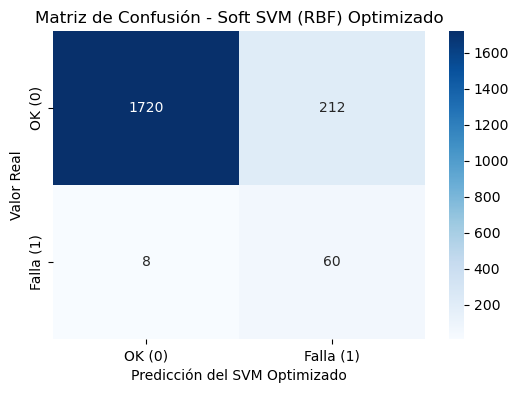

In [4]:


######## Separamos las variables independientes y dependientes
# ADEMÁS de la variable objetivo, eliminamos las variables de modo de falla 
# para evitar la "Fuga de Datos" (Data Leakage)
X = df_clean.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df_clean['Machine failure']

######### Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y) ####### Estratificamos por el desbalance de clases

######### Estandarizamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Ajustamos el modelo en el conjunto de entrenamiento
X_test_scaled = scaler.transform(X_test)       # Solo transformamos la sección de conjunto de prueba

# Entrenar un modelo de Random Forest para evaluar la importancia
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# Extraer y ordenar las importancias
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

# Graficar la importancia de las variables
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features[indices], hue=features[indices], palette="viridis", legend=False)
plt.title('Importancia de las Variables - Random Forest')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.show()

# Entrenar un modelo lineal (Regresión Logística) usando los mismos datos balanceados
linear_model = LogisticRegression(class_weight='balanced', random_state=42)
linear_model.fit(X_train_scaled, y_train)

# Realizar predicciones
y_pred_linear = linear_model.predict(X_test_scaled)

# Evaluar el modelo lineal
print("REPORTE DE CLASIFICACIÓN - MODELO LINEAL (Regresión Logística)")
print(classification_report(y_test, y_pred_linear))


# Definir el espacio de búsqueda para C y gamma
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# Configurar GridSearchCV priorizando el 'recall' (encontrar las fallas es lo más crítico)
grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,               # Validación cruzada de 5 particiones
    scoring='recall',   # Métrica a optimizar
    n_jobs=-1           # Usa todos los núcleos de tu PC para que sea más rápido
)

print("Iniciando búsqueda de hiperparámetros... (esto puede tardar unos segundos)")
grid_search.fit(X_train_scaled, y_train)

print(f"\n¡Listo! Mejores hiperparámetros encontrados: {grid_search.best_params_}")

# Evaluar el mejor modelo encontrado
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)

print("\nREPORTE DE CLASIFICACIÓN - SVM OPTIMIZADO")
print(classification_report(y_test, y_pred_best))

######### Graficar la Matriz de Confusión del Modelo Optimizado
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['OK (0)', 'Falla (1)'], 
            yticklabels=['OK (0)', 'Falla (1)'])

plt.xlabel('Predicción del SVM Optimizado')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Soft SVM (RBF) Optimizado')
plt.show()

Iniciando búsqueda de hiperparámetros para Random Forest... (esto puede tardar un poco)

¡Listo! Mejores hiperparámetros encontrados para RF: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}

REPORTE DE CLASIFICACIÓN - RANDOM FOREST OPTIMIZADO
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.63      0.72      0.67        68

    accuracy                           0.98      2000
   macro avg       0.81      0.85      0.83      2000
weighted avg       0.98      0.98      0.98      2000



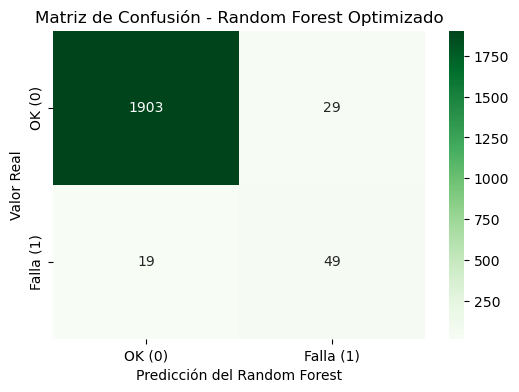

In [5]:

# Definir el espacio de búsqueda para los hiperparámetros del Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],      # Número de árboles en el bosque
    'max_depth': [None, 10, 20],         # Profundidad máxima de cada árbol
    'min_samples_split': [2, 5, 10]      # Mínimo de muestras para dividir un nodo
}

# Configurar GridSearchCV priorizando el 'recall' para buscar fallas
grid_search_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    cv=5,               # Validación cruzada de 5 particiones
    scoring='recall',   # Métrica a optimizar
    n_jobs=-1           # Usa todos los núcleos
)

print("Iniciando búsqueda de hiperparámetros para Random Forest... (esto puede tardar un poco)")
grid_search_rf.fit(X_train_scaled, y_train)

print(f"\n¡Listo! Mejores hiperparámetros encontrados para RF: {grid_search_rf.best_params_}")

# Evaluar el mejor Random Forest encontrado
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

print("\nREPORTE DE CLASIFICACIÓN - RANDOM FOREST OPTIMIZADO")
print(classification_report(y_test, y_pred_rf))

# Graficar la Matriz de Confusión del Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['OK (0)', 'Falla (1)'], 
            yticklabels=['OK (0)', 'Falla (1)'])

plt.xlabel('Predicción del Random Forest')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Random Forest Optimizado')
plt.show()